# 🎓 Student Placement Prediction — Advanced Classification Portfolio Project

---

| Field | Details |
|---|---|
| **Dataset** | Campus Recruitment dataset — `Placement_Data_Full_Class.csv` (Kaggle) |
| **Type** | Supervised Learning · Binary Classification |
| **Level** | Advanced · Portfolio Grade |
| **Models** | Logistic Regression · KNN · Naive Bayes · SVM · Random Forest · Gradient Boosting |
| **Advanced** | ROC-AUC · Precision-Recall Curves · SMOTE · class_weight · GridSearchCV · Learning Curves · Probability Calibration · Feature Importance |

---

## 📌 Project Objective

Predict whether a student will be **placed (hired)** or **not placed** based on academic records and test scores.

This is a **binary classification** problem with real-world stakes:
- A college wants to identify **at-risk students** early and provide targeted support
- An accurate model can guide resource allocation for placement training

**Kaggle dataset challenges:**
- Real data with missing values and mixed data types
- Moderate class imbalance
- Categorical features requiring encoding
- Feature selection from a meaningful but limited feature set


## Section 01

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

from scipy import stats

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# SMOTE for Class imbalance

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
    print("Imbalanced-learn available")

except ImportError:
    SMOTE_AVAILABLE = False
    print("imbalanced-learn not installed.")

RANDOM_STATE = 42

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')
print('All Library Loaded. Lets get started...')


Imbalanced-learn available
All Library Loaded. Lets get started...


## Section 2 - Data Loading 

**Dataset:** Download `Placement_Data_Full_Class.csv` from
[Kaggle — Campus Recruitment](https://www.kaggle.com/benroshan/factors-affecting-campus-placement)

| Column | Description |
|---|---|
| `sl_no` | Serial number (drop — not a feature) |
| `gender` | Male / Female |
| `ssc_p` | Secondary school % (10th grade) |
| `ssc_b` | Secondary school board (Central / Others) |
| `hsc_p` | Higher secondary % (12th grade) |
| `hsc_b` | Higher secondary board |
| `hsc_s` | Higher secondary stream (Science/Commerce/Arts) |
| `degree_p` | Degree percentage |
| `degree_t` | Degree type |
| `workex` | Work experience (Yes/No) |
| `etest_p` | Employability test percentage |
| `specialisation` | MBA specialisation (Mkt&HR / Mkt&Fin) |
| `mba_p` | MBA percentage |
| `status` | **Target** — Placed / Not Placed |
| `salary` | Salary offered (only if placed — we will drop this to avoid leakage) |

In [3]:
df = pd.read_csv('Data\Placement_Data_Full_Class.csv')

print(f"Dataset Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nTarget Distribution: ")
print(df['status'].value_counts())
print(f"\nPlacement Rate: {(df["status"] == "Placed").mean()*100:.1f}%")

df.head()


Dataset Loaded: 215 rows x 15 columns

Columns: ['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']

Target Distribution: 
status
Placed        148
Not Placed     67
Name: count, dtype: int64

Placement Rate: 68.8%


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


## Section 3 - Exploratory Data Analysis (EDA)

In [4]:
# 3.1 Overview

print("Missing Values: ")
print(df.isnull().sum())
print(f"\n Salary is missing for {df['salary'].isnull().sum()} records, which is expected for 'Not Placed' students.")
print("\nData Types: ")
print(df.dtypes)

Missing Values: 
sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

 Salary is missing for 67 records, which is expected for 'Not Placed' students.

Data Types: 
sl_no               int64
gender                str
ssc_p             float64
ssc_b                 str
hsc_p             float64
hsc_b                 str
hsc_s                 str
degree_p          float64
degree_t              str
workex                str
etest_p           float64
specialisation        str
mba_p             float64
status                str
salary            float64
dtype: object


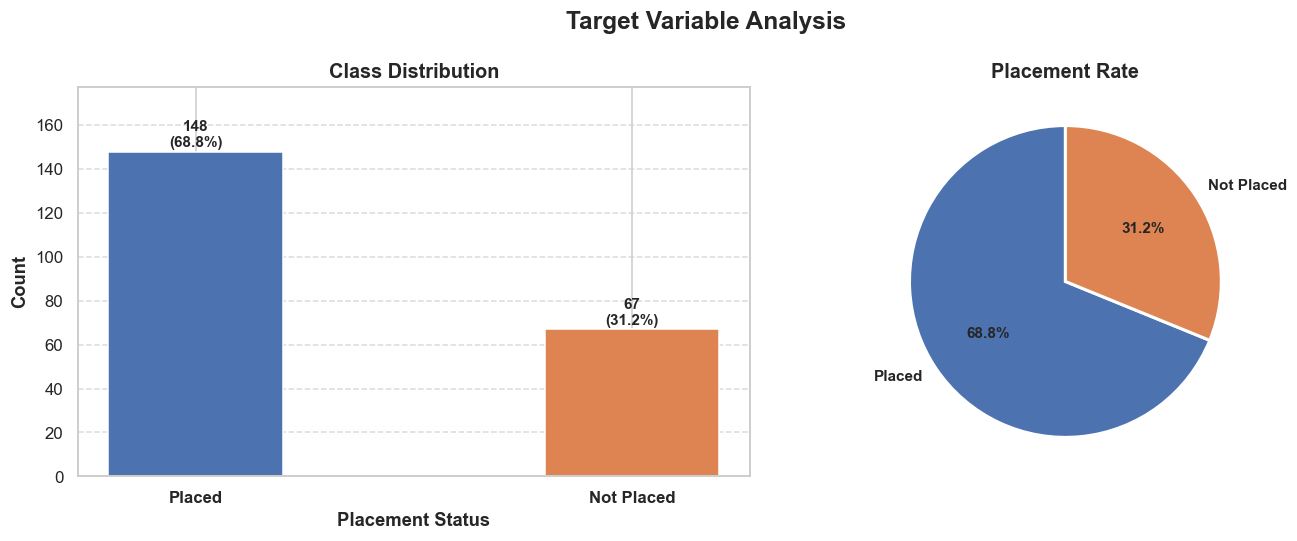

Imbalance Ratio: 2.21 (Not Placed : Placed)
Class imbalance is moderate. Standard modeling techniques may perform adequately, but always evaluate with appropriate metrics.


In [8]:
# 3.2 Class Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['status'].value_counts()
colors = ['#4c72b0', '#dd8452']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.4)

for i, (label, v) in enumerate(counts.items()):
    axes[0].text(i, v+2, f"{v}\n({v/len(df)*100:.1f}%)", ha='center', fontsize=10, fontweight='bold')

axes[0].set_title("Class Distribution", fontweight='bold', fontsize=13)
axes[0].set_ylabel("Count", fontweight='bold')
axes[0].set_xlabel("Placement Status", fontweight='bold')
axes[0].set_ylim(0, counts.max()*1.2)
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(counts.index, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Pie Chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Placement Rate", fontweight='bold', fontsize=13)

plt.suptitle("Target Variable Analysis", fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f} (Not Placed : Placed)")
if imbalance_ratio > 3:
    print("Warning: Significant class imbalance detected. Consider using techniques like SMOTE or class weighting during model training.")
else:
    print("Class imbalance is moderate. Standard modeling techniques may perform adequately, but always evaluate with appropriate metrics.")

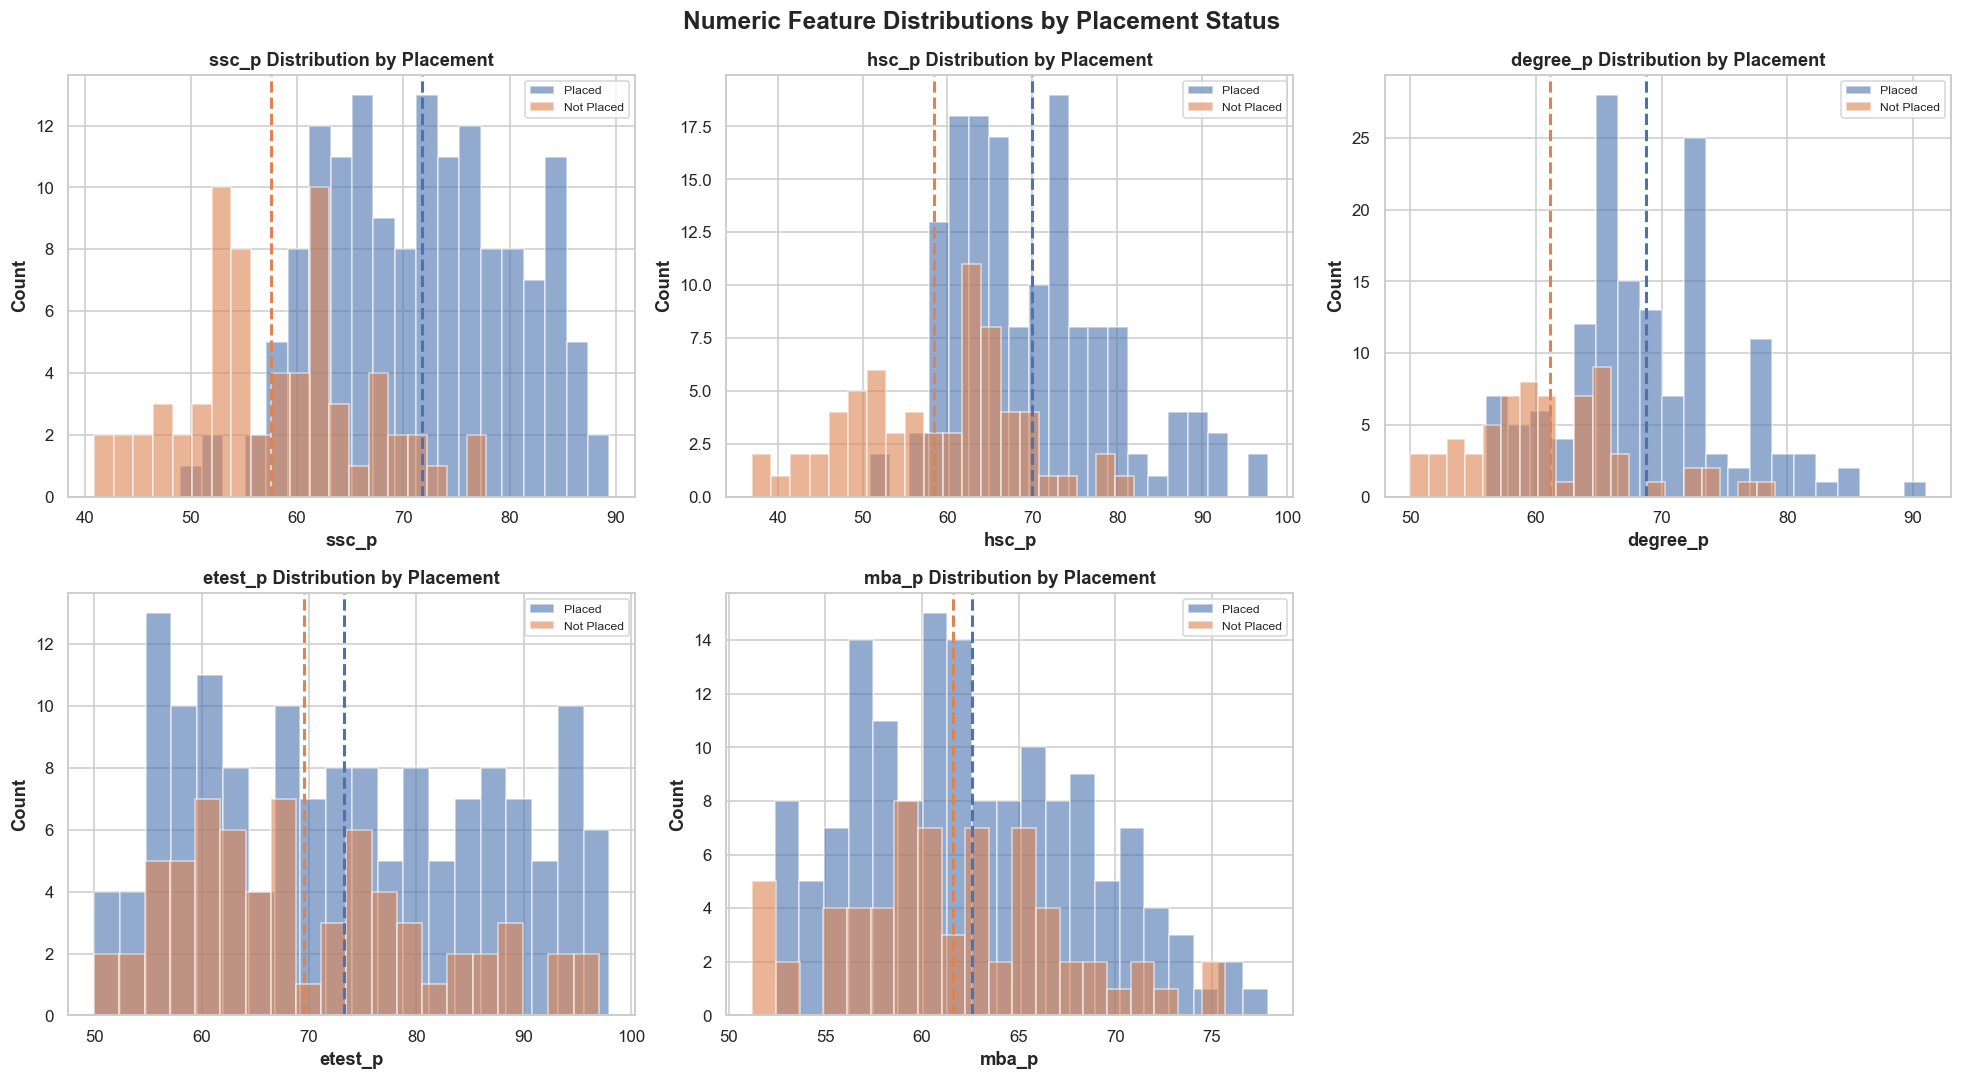

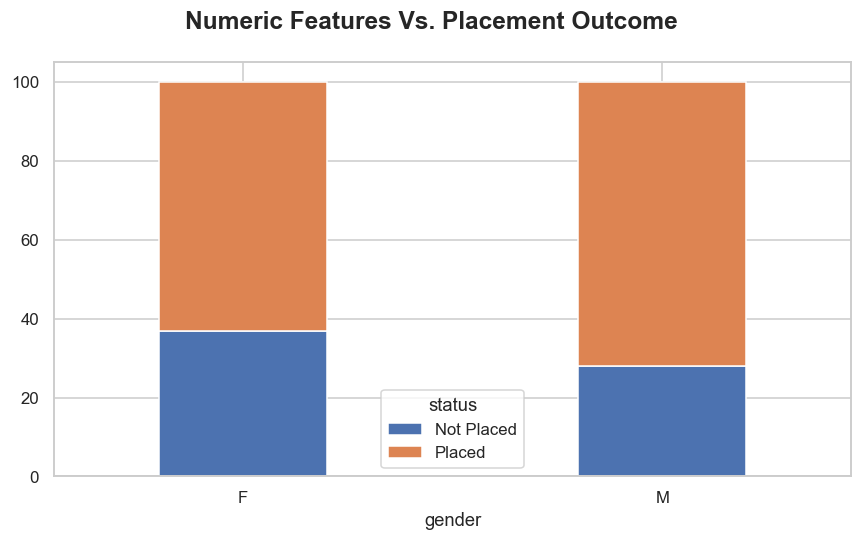

In [7]:
# 3.3 Numeric feature Distribution by Placement

num_feats = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
palette = {'Placed': '#4c72b0', 'Not Placed': '#dd8452'}

for i, feat in enumerate(num_feats):
    for label, color in palette.items():
        subset = df[df['status'] == label][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
        axes[i].axvline(subset.mean(), color=color, linestyle='dashed', linewidth=2)
    axes[i].set_title(f"{feat} Distribution by Placement", fontweight='bold')
    axes[i].set_xlabel(feat, fontweight='bold')
    axes[i].set_ylabel("Count", fontweight='bold')
    axes[i].legend(fontsize=8)
axes[-1].axis('off')
plt.suptitle("Numeric Feature Distributions by Placement Status", fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

# Placement by gender

gender_cross = pd.crosstab(df['gender'], df['status'], normalize='index') * 100
gender_cross.plot(kind='bar', stacked=True, color=colors, edgecolor='white', figsize=(8, 5), width=0.4, rot=0)
axes[5].set_title("Placement by Gender", fontweight="bold")
axes[5].legend(title="Placement Status", fontsize=8)

plt.suptitle("Numeric Features Vs. Placement Outcome", fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

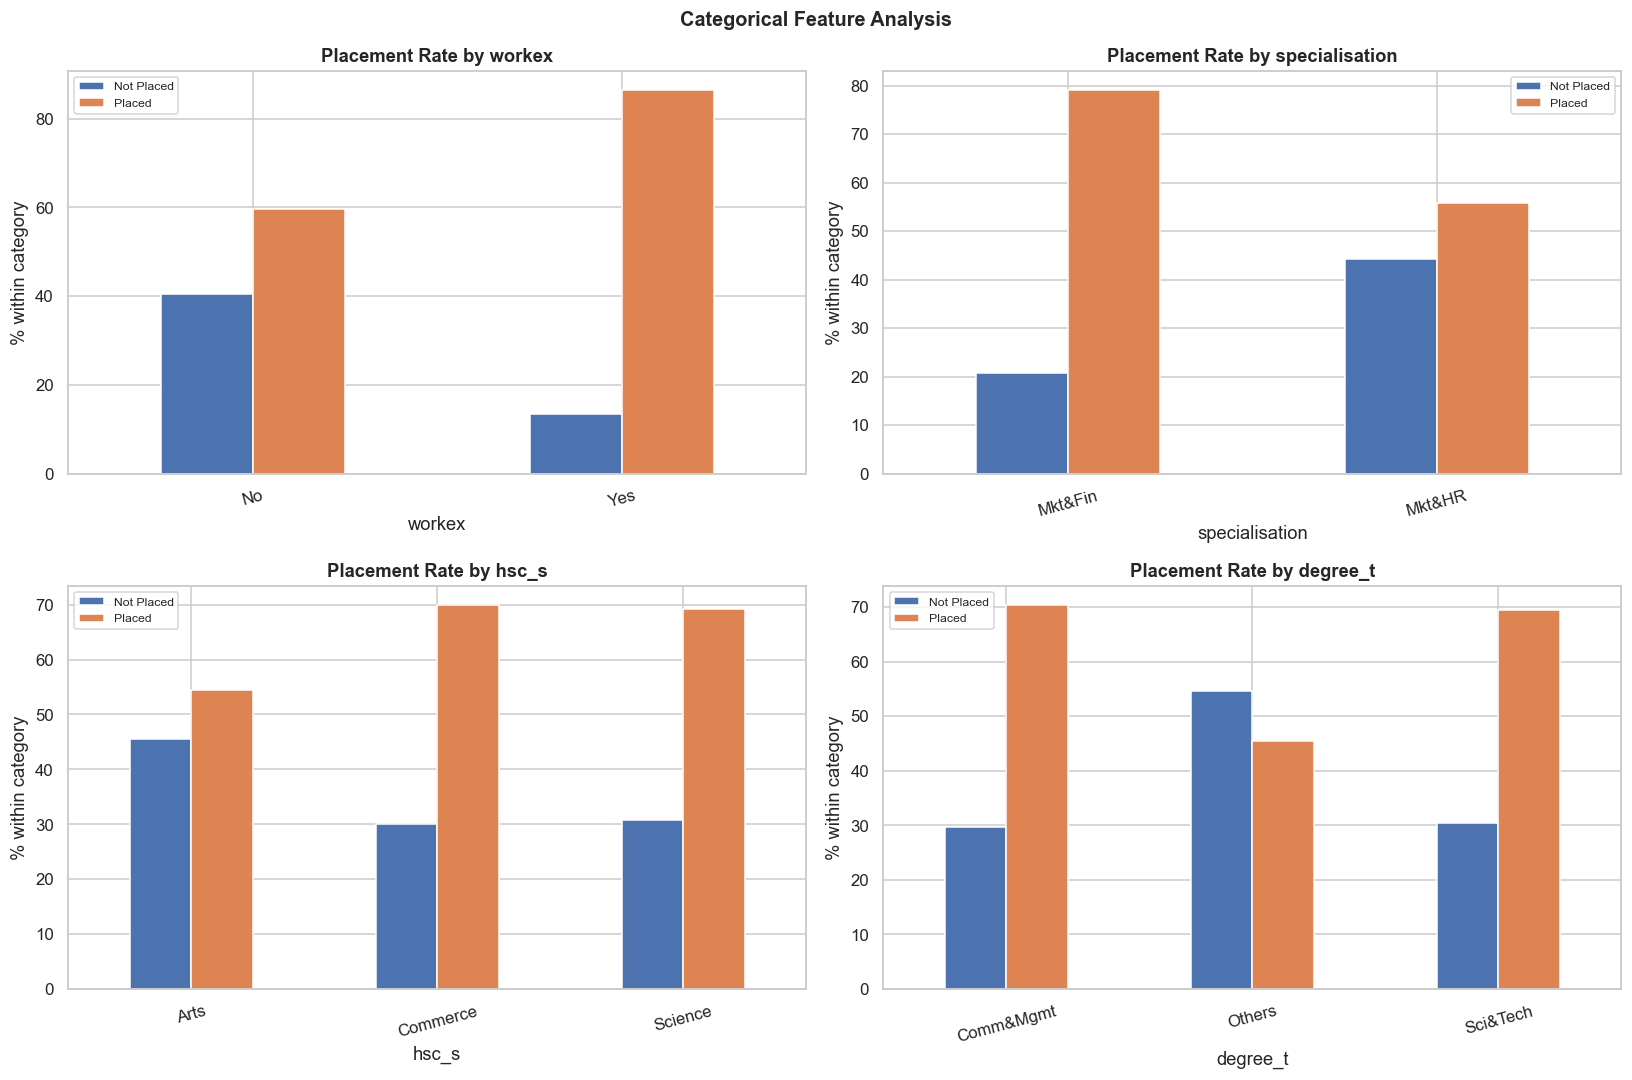

In [9]:
# 3.4 Categorical Features Vs. Placement

cat_feats = ['workex','specialisation','hsc_s','degree_t']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, feat in zip(axes.flatten(), cat_feats):
    ct = pd.crosstab(df[feat], df['status'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=colors, edgecolor='white', rot=15)
    ax.set_title(f'Placement Rate by {feat}', fontweight='bold')
    ax.set_ylabel('% within category')
    ax.legend(fontsize=8)

plt.suptitle('Categorical Feature Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


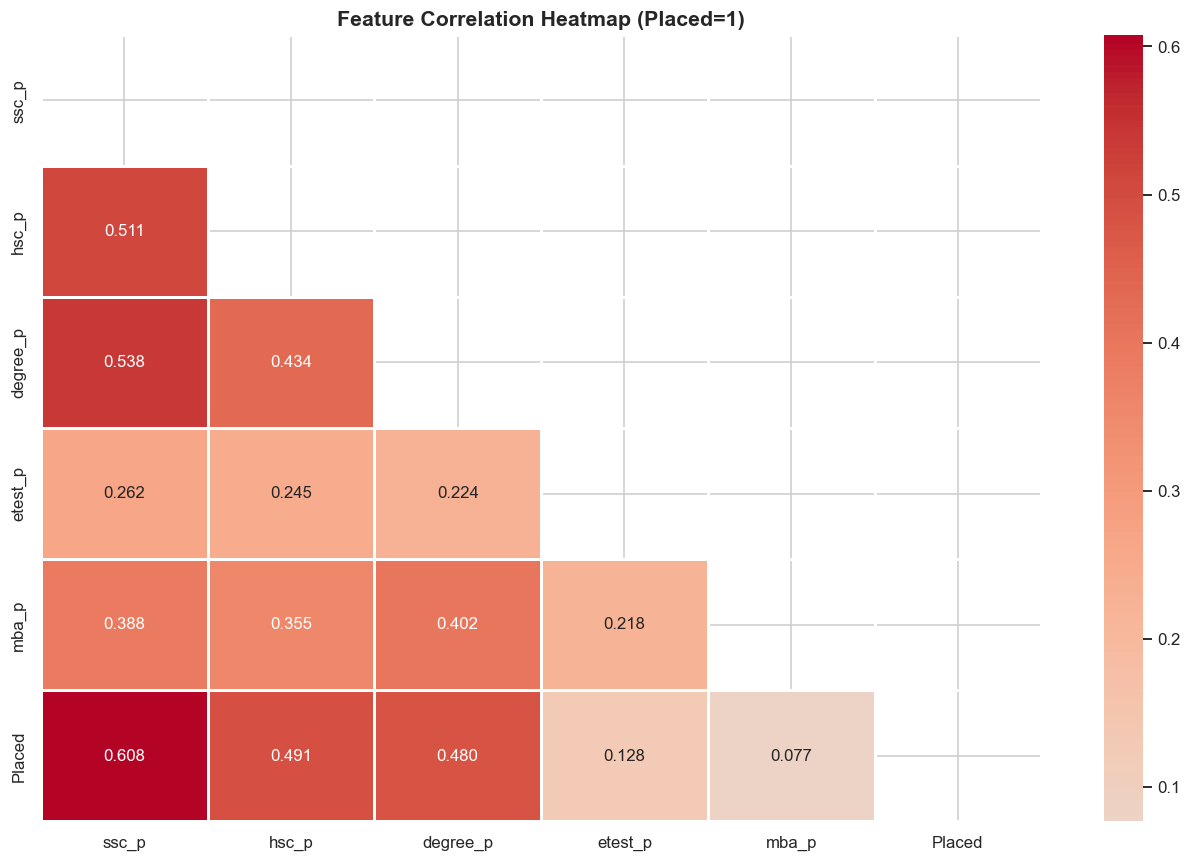

Correlation with Placement outcome:
ssc_p       0.607889
hsc_p       0.491228
degree_p    0.479861
etest_p     0.127639
mba_p       0.076922


In [10]:
# 3.5 Correlation Analysis

fig, ax = plt.subplots(figsize=(12, 8))
numeric_df = df[num_feats + ['status']].copy()
numeric_df['Placed'] = (numeric_df['status'] == 'Placed').astype(int)
numeric_df = numeric_df.drop(columns='status')

corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.8, ax=ax, annot_kws={'size':11})
ax.set_title('Feature Correlation Heatmap (Placed=1)', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

print('Correlation with Placement outcome:')
print(corr['Placed'].drop('Placed').sort_values(ascending=False).to_string())

## Section 4 - Data Preprocessing



### Key Steps
1. Drop `sl_no` (just a row number) and `salary` (**data leakage** — salary only exists if placed)
2. Encode categorical features
3. Stratified train-test split
4. StandardScaler (fit on train only)

### ⚠️ Why Drop Salary?
`salary` is only filled for students who were **placed**. It is 100% correlated with the target — if salary is present, status=Placed. Including it would give the model a perfect cheat code, resulting in 100% accuracy that tells us nothing. This is called **data leakage**.


In [11]:
# 4.1 Drop Leakage Columns

df_clean = df.drop(columns=['sl_no', 'salary'])
print(f"Shape after dropping leakage columns: {df_clean.shape}")

Shape after dropping leakage columns: (215, 13)


In [13]:
# 4.2 Encode Categorical Features

cat_cols = df_clean.select_dtypes(include='object').columns.drop('status')
print(f"Categorical columns to encode: {list(cat_cols)}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    le_dict[col]  = le


Categorical columns to encode: []


In [14]:
# 4.3 Encode Target Variable

df_clean["Placed"] = (df_clean['status'] == 'Placed').astype(int)
df_clean = df_clean.drop(columns='status')

x = df_clean.drop(columns='Placed')
y = df_clean['Placed']

print(f"Final feature set shape: {x.shape}")
print(f"Target Distribution: Placed={y.sum()} ({y.mean()*100:.1f}%), Not Placed={len(y) - y.sum()} ({(1-y.mean())*100:.1f}%)")

Final feature set shape: (215, 12)
Target Distribution: Placed=148 (68.8%), Not Placed=67 (31.2%)


In [15]:
# 4.4 Stratified Train-Test Split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


print(f'Train: {x_train.shape[0]} samples | Placed: {y_train.mean()*100:.1f}%')
print(f'Test : {x_test.shape[0]}  samples | Placed: {y_test.mean()*100:.1f}%')


Train: 172 samples | Placed: 68.6%
Test : 43  samples | Placed: 69.8%


In [16]:
# 4.5 StandardScaler

scaler         = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

print("\n Data preprocessing completed. Ready for modeling.")


 Data preprocessing completed. Ready for modeling.


## Section 5 - Modeling and Evaluation

| # | Model | Key Strength |
|---|---|---|
| 1 | Logistic Regression | Interpretable baseline, probability output |
| 2 | KNN | Non-parametric, simple |
| 3 | Naive Bayes | Fast, probabilistic |
| 4 | SVM (RBF) | Powerful on high-dimensional data |
| 5 | Random Forest | Robust ensemble, feature importance |
| 6 | Gradient Boosting | Highest accuracy, handles complex patterns |
| 7 | XGBoost | State-of-the-art boosting, regularization |
| 8 | LightGBM | Fast, efficient boosting for large datasets |
| 9 | CatBoost | Handles categorical features natively, robust to overfitting |